In [49]:
import torch
import numpy as np
from typing import List,Literal,Type 
import matplotlib.pyplot as plt

In [50]:
from inference import load_diffusion_model, ddim_reverse_step,reverse_diffusion_ddim, make_ddim_timesteps
from diffusion import DiffusionSchedule,diffuse
from network import UNetDiffusion

In [68]:
N_STEPS = 1000
T_START = 600
K = 10
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

In [52]:
model,schedule = load_diffusion_model(ckpt_path="../models/unet32.pt",device=device)


In [53]:
patch = np.load("../dataset/test/patch_9107_22.npy").astype(np.float32).squeeze()
patch = (patch - patch.mean()) / (patch.std() + 1e-8)

x0 = torch.from_numpy(patch)[None, None].to(schedule.device)  # (1, 1, 48, 48)
t = torch.tensor([T_START], device=x0.device)

xt, noise = diffuse(x0, t, schedule)

In [54]:
def _check_steps_inputs(K:int,t_start:int, schedule:DiffusionSchedule):
    if not 0 <= t_start < schedule.timesteps:
        raise ValueError("t_start must be in [0, schedule.timesteps - 1]")
    if not 1 <= K <= t_start + 1:
        raise ValueError("K must be in [1, t_start + 1]")

In [55]:

def linear_timesteps(K:int,t_start:int, schedule:DiffusionSchedule)->List[int]:
    _check_steps_inputs(K,t_start,schedule)
    linear_steps = make_ddim_timesteps(
        num_ddim_steps=K,
        num_diffusion_steps=schedule.timesteps,
        t_start=t_start,
    )
    return linear_steps

lin_steps = linear_timesteps(K,T_START,schedule)

In [56]:
def quadratic_timesteps(K:int, schedule:DiffusionSchedule, t_start:int,*, curve:float)->List[int]:
    _check_steps_inputs(K,t_start,schedule)
    n = K-1
    slope = (t_start- curve * n**2)/n
    steps = [round((curve*(x**2))+ slope*x) for x in range(K)] 
    return steps[::-1]

In [57]:
def uniform_log_snr_steps(K: int, t_start: int, schedule: DiffusionSchedule) -> List[int]:
    """Choose K reverse timesteps evenly spaced in the schedule's log-SNR."""
    _check_steps_inputs(K,t_start,schedule)
    alpha_bar = schedule.alpha_bar[: t_start + 1].detach().to("cpu", dtype=torch.float64)
    log_snr = torch.log(alpha_bar) - torch.log1p(-alpha_bar)
    targets = torch.linspace(
        log_snr[t_start].item(), log_snr[0].item(), K, dtype=torch.float64
    )
    steps = [t_start]
    for i, target in enumerate(targets[1:-1], start=1):
        nearest = int(torch.argmin(torch.abs(log_snr - target)))
        # Reserve one distinct integer timestep for every remaining step.
        lower = K - 1 - i
        upper = steps[-1] - 1
        steps.append(min(max(nearest, lower), upper))
    steps.append(0)
    return steps

log_snr_steps = uniform_log_snr_steps(K, T_START, schedule)
log_snr_steps

[600, 2, 1, 0]

In [58]:
x0_hat, scores = reverse_diffusion_ddim(xt,lin_steps,model,schedule)

In [70]:
def compute_residual_map(x0: torch.Tensor, x0_hat: torch.Tensor, metric: str = "pdf_relative") -> torch.Tensor:
    diff = x0 - x0_hat
    abs_diff = torch.abs(diff)
    
    if metric == "pdf_relative":
        return abs_diff / (1.0 + torch.abs(x0_hat))
    elif metric == "squared":
        return diff.pow(2)
    elif metric == "absolute":
        return abs_diff
    elif metric == "signed_positive":
        # Ne garde que les pixels plus lumineux que le fond reconstruit[cite: 1]
        return torch.maximum(torch.tensor(0.0, device=x0.device), diff)
    else:
        raise ValueError(f"Métrique inconnue : {metric}")

In [71]:
def evaluate_residual_contrast(residual_map: torch.Tensor) -> float:
    """
    Evaluate the constrast of the residual map
    Difference between a percentile (e.g. 99th) and the median of the residual map
    """
    res_flat = residual_map.flatten()
    # Calcul du 99e percentile et de la médiane
    p99 = torch.quantile(res_flat, 0.99)
    median = torch.median(res_flat)
    
    # Le score est le contraste entre les valeurs extrêmes et le fond
    contrast_score = (p99 - median).item()
    return contrast_score

In [72]:
def sweep_t_start(
    x0: torch.Tensor, 
    model: torch.nn.Module, 
    schedule, 
    t_starts: list[int], 
    K: int, 
    seed: int = 42,
    metric: str = "pdf_relative"
):
    results = []
    
    for t_start in t_starts:
        # Accumulateur pour moyenner les reconstructions et annuler le bruit[cite: 1]
        torch.manual_seed(seed)  

        # Bruitage
        t_tensor = torch.tensor([t_start], device=x0.device)
        xt, _ = diffuse(x0, t_tensor, schedule)

        # Denoising
        steps = make_ddim_timesteps(num_ddim_steps=K, num_diffusion_steps=schedule.timesteps, t_start=t_start)
        x0_hat, _ = reverse_diffusion_ddim(xt, steps, model, schedule)
                
        # Calcul de la carte d'erreur et du score de contraste
        res_map = compute_residual_map(x0, x0_hat, metric=metric)
        contrast = evaluate_residual_contrast(res_map)
        
        results.append({
            "t_start": t_start,
            "contrast_score": contrast,
            "residual_map": res_map.squeeze().cpu().numpy()
        })
        print(f"t_start={t_start:>3} | Contraste (P99 - Median)={contrast:.4f}")
        
    return results

# Exécution
model, schedule = load_diffusion_model(ckpt_path="../models/unet32.pt", device=device)
patch = np.load("../dataset/test/patch_9107_22.npy").astype(np.float32).squeeze()
patch = (patch - patch.mean()) / (patch.std() + 1e-8)
x0 = torch.from_numpy(patch)[None, None].to(device)

t_starts_to_scan = [200, 400, 600, 800]
results = sweep_t_start(x0, model, schedule, t_starts_to_scan, K=K, seed=42, metric="pdf_relative")

t_start=200 | Contraste (P99 - Median)=0.7524
t_start=400 | Contraste (P99 - Median)=1.2367
t_start=600 | Contraste (P99 - Median)=1.6540
t_start=800 | Contraste (P99 - Median)=1.7580


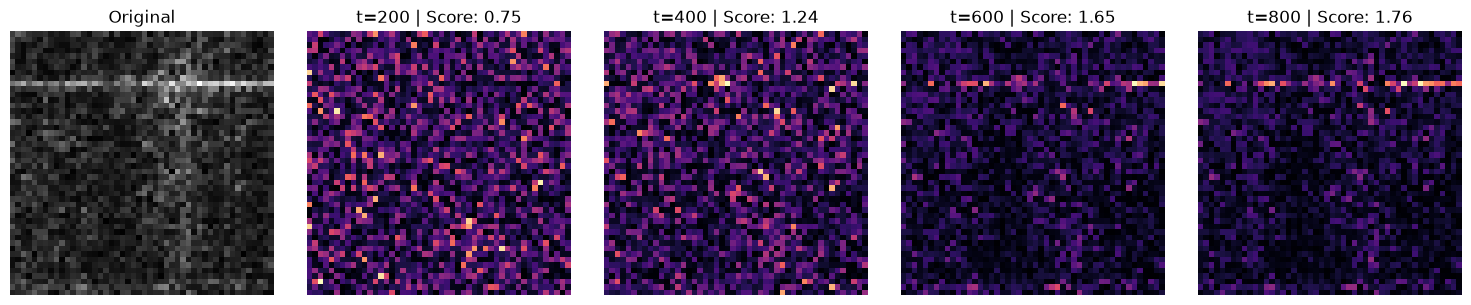

In [73]:
fig, axes = plt.subplots(1, len(results) + 1, figsize=(15, 3))
axes[0].imshow(x0.squeeze().cpu().numpy(), cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

for i, res in enumerate(results):
    ax = axes[i + 1]
    im = ax.imshow(res["residual_map"], cmap='magma')
    ax.set_title(f"t={res['t_start']} | Score: {res['contrast_score']:.2f}")
    ax.axis('off')

plt.tight_layout()
plt.show()

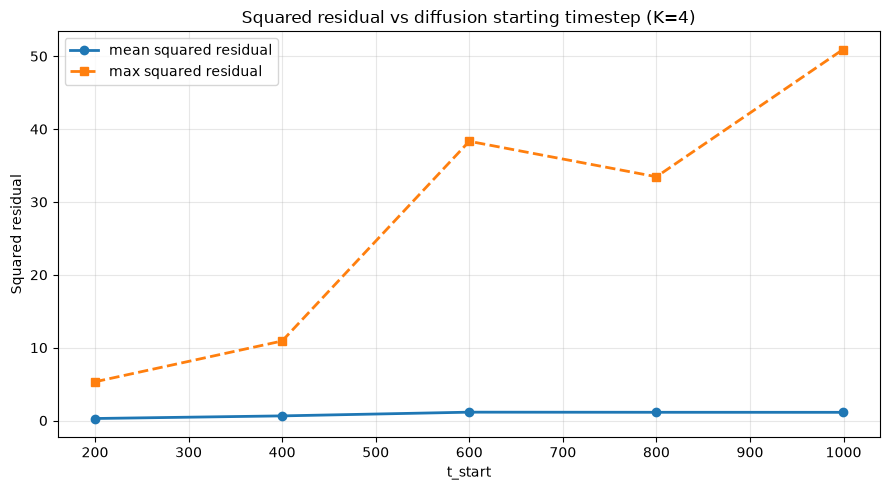

In [61]:
# figure: trend of the squared residual across different t_start values
if squared_residual_scan:
    t_starts_plot = [record["t_start"] for record in squared_residual_scan]
    mean_sq_plot = [record["mean_squared_residual"] for record in squared_residual_scan]
    max_sq_plot = [record["max_squared_residual"] for record in squared_residual_scan]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(t_starts_plot, mean_sq_plot, marker="o", linewidth=2, label="mean squared residual")
    ax.plot(t_starts_plot, max_sq_plot, marker="s", linestyle="--", linewidth=2, label="max squared residual")
    ax.set_xlabel("t_start")
    ax.set_ylabel("Squared residual")
    ax.set_title(f"Squared residual vs diffusion starting timestep (K={K})")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No scan results available yet.")
